# EE 608 – Applied Modeling and Optimization
## Project: AI driven wireless networking : QoS-Aware Bandwidth Allocation in 5G Networks

**Team Members: Charaneesh Gadikota, Divya Prahlad, Samarth Venkatesh Murthy
  
**Dataset:** [5G Resource Allocation Dataset – Kaggle](https://www.kaggle.com/datasets/omarsobhy14/5g-quality-of-service)

---

### Problem Overview
Given 400 users on a 5G network, each with different signal conditions and bandwidth requirements, we formulate and solve an optimization problem to **maximize total network throughput** while ensuring every user receives at least their minimum required bandwidth.

### Optimization Model
- **Decision variable:** $x_i$ = bandwidth allocated to user $i$ (Mbps)
- **Objective:** $\max \sum_{i=1}^{n} \log(1 + \gamma_i \cdot x_i)$ — Shannon-capacity-inspired throughput
- **Constraints:**
  - $\sum_{i} x_i \leq B$ — total bandwidth budget
  - $x_i \geq b_i$ — each user gets at least their required bandwidth
  - $x_i \geq 0$ — non-negativity

Since $\log(1 + \gamma x)$ is **concave** in $x$, maximizing a sum of concave functions is a **convex optimization problem**, guaranteeing a global optimum.

---
## Step 1: Data Loading, Cleaning & Exploratory Analysis

The dataset contains raw string values with units embedded (e.g., `-75 dBm`, `10 Mbps`, `30 ms`).  
We parse and convert all columns to numeric values for use in the optimization model.

**Column mapping to model variables:**
| Dataset Column | Model Role |
|---|---|
| `Signal_Strength` | $\gamma_i$ — channel quality per user |
| `Required_Bandwidth` | $b_i$ — minimum bandwidth constraint |
| `Allocated_Bandwidth` | Baseline to compare against optimized result |
| `Latency` | QoS reference metric |
| `Application_Type` | Grouping variable for insights |

(400, 13)
       Signal_Strength_dBm  Latency_ms  Required_BW_Mbps  Allocated_BW_Mbps  \
count                400.0      400.00            400.00             400.00   
mean                 -80.5       33.83              3.14               3.50   
std                   20.7       21.12              3.98               4.46   
min                 -123.0        0.00              0.00               0.00   
25%                  -98.0       21.75              0.42               0.42   
50%                  -83.0       31.00              1.20               1.35   
75%                  -64.0       45.00              4.10               4.43   
max                  -40.0      110.00             14.50              15.80   

       Resource_Alloc_pct  
count              400.00  
mean                74.71  
std                  8.98  
min                 50.00  
25%                 70.00  
50%                 70.00  
75%                 80.00  
max                 90.00  
Application_Type
Video_Cal

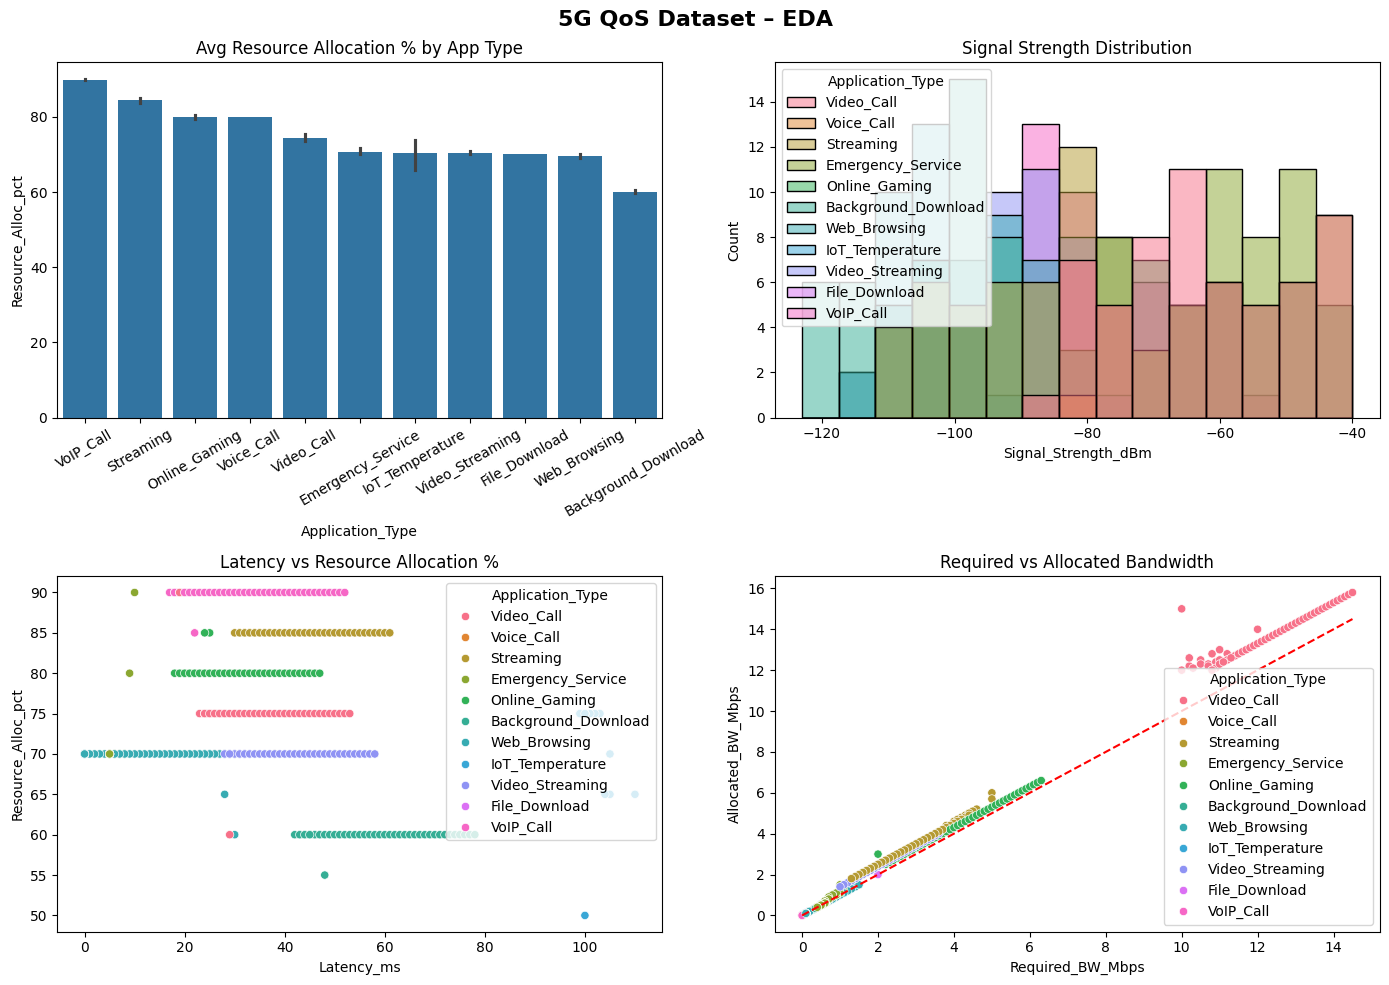

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('/Quality_of_Service_5G.csv')  # update path if needed

# ── Clean ─────────────────────────────────────────────────────────────────────
def to_mbps(val):
    val = str(val).strip()
    num = float(re.findall(r'[\d.]+', val)[0])
    if 'Kbps' in val or 'kbps' in val:
        return num / 1000
    return num

df['Signal_Strength_dBm']  = df['Signal_Strength'].str.extract(r'([-\d]+)').astype(float)
df['Latency_ms']           = df['Latency'].str.extract(r'([\d.]+)').astype(float)
df['Required_BW_Mbps']     = df['Required_Bandwidth'].apply(to_mbps)
df['Allocated_BW_Mbps']    = df['Allocated_Bandwidth'].apply(to_mbps)
df['Resource_Alloc_pct']   = df['Resource_Allocation'].str.replace('%','').astype(float)
df['Timestamp']            = pd.to_datetime(df['Timestamp'])

# ── Explore ───────────────────────────────────────────────────────────────────
print(df.shape)
print(df[['Signal_Strength_dBm','Latency_ms','Required_BW_Mbps',
          'Allocated_BW_Mbps','Resource_Alloc_pct']].describe().round(2))
print(df['Application_Type'].value_counts())
print(df.groupby('Application_Type')['Resource_Alloc_pct'].mean().sort_values(ascending=False).round(2))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('5G QoS Dataset – EDA', fontsize=16, fontweight='bold')

order = df.groupby('Application_Type')['Resource_Alloc_pct'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Application_Type', y='Resource_Alloc_pct', order=order, ax=axes[0,0])
axes[0,0].set_title('Avg Resource Allocation % by App Type')
axes[0,0].tick_params(axis='x', rotation=30)

sns.histplot(data=df, x='Signal_Strength_dBm', hue='Application_Type', bins=15, ax=axes[0,1])
axes[0,1].set_title('Signal Strength Distribution')

sns.scatterplot(data=df, x='Latency_ms', y='Resource_Alloc_pct', hue='Application_Type', ax=axes[1,0])
axes[1,0].set_title('Latency vs Resource Allocation %')

sns.scatterplot(data=df, x='Required_BW_Mbps', y='Allocated_BW_Mbps', hue='Application_Type', ax=axes[1,1])
axes[1,1].plot([0, df['Required_BW_Mbps'].max()], [0, df['Required_BW_Mbps'].max()], 'r--')
axes[1,1].set_title('Required vs Allocated Bandwidth')

plt.tight_layout()
plt.savefig('eda_5g.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2: Optimization Model – cvxpy Implementation

We use **cvxpy** to solve the convex optimization problem.

**Signal quality ($\gamma_i$):** Derived by normalizing `Signal_Strength_dBm` to $(0, 1]$.  
Higher $\gamma_i$ means better signal → more throughput gain per unit bandwidth.

**Budget ($B$):** Set to 110% of total required bandwidth, giving the optimizer 10% headroom to redistribute.

**Solver:** We use `SCS` (Splitting Conic Solver), a first-order solver well-suited for large-scale convex problems like this one.

Total budget: 1379.63 Mbps | Users: 400

Status:           optimal
Objective value:  355.6997
Total allocated:  1379.62 Mbps (budget: 1379.63 Mbps)

=== Avg Allocated BW: Original vs Optimized (by App Type) ===
                     Allocated_BW_Mbps  Optimized_BW_Mbps
Application_Type                                         
Background_Download             0.5489             0.5546
Emergency_Service               0.7447             1.9952
File_Download                   2.0000             2.0000
IoT_Temperature                 0.0052             0.0510
Online_Gaming                   4.4556             4.1400
Streaming                       3.8936             3.3532
Video_Call                     13.2841            11.8304
Video_Streaming                 3.3149             2.9383
VoIP_Call                       0.1041             1.3965
Voice_Call                      0.1200             1.3053
Web_Browsing                    0.4875             0.4875


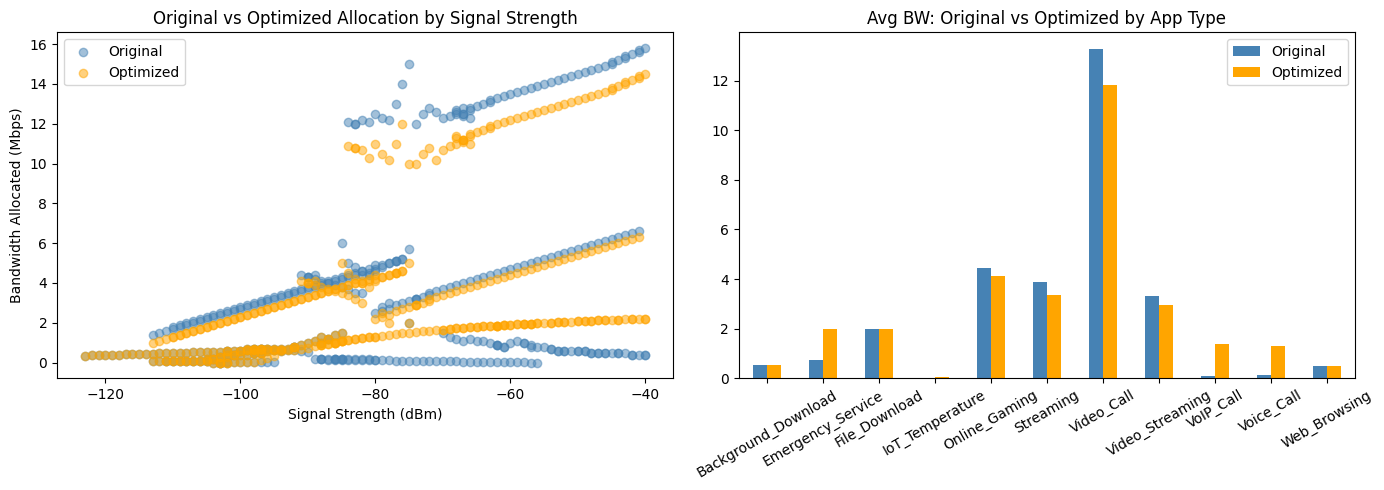

In [ ]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# ── Prep inputs from cleaned df ───────────────────────────────────────────────
signal  = df['Signal_Strength_dBm'].values
req_bw  = df['Required_BW_Mbps'].values
n       = len(df)

# gamma_i: normalize signal strength to (0,1] — higher = better signal
gamma = (signal - signal.min()) / (signal.max() - signal.min()) + 0.01

# Total bandwidth budget = sum of required + 10% headroom
B = req_bw.sum() * 1.1
print(f"Total budget: {B:.2f} Mbps | Users: {n}")

# ── Optimization Model ────────────────────────────────────────────────────────
x = cp.Variable(n, nonneg=True)

objective = cp.Maximize(cp.sum(cp.log(1 + cp.multiply(gamma, x))))

constraints = [
    cp.sum(x) <= B,    # total bandwidth budget
    x >= req_bw,       # every user gets at least their required BW
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

print(f"\nStatus:           {prob.status}")
print(f"Objective value:  {prob.value:.4f}")
print(f"Total allocated:  {x.value.sum():.2f} Mbps (budget: {B:.2f} Mbps)")

# ── Compare optimized vs original allocation ──────────────────────────────────
df['Optimized_BW_Mbps'] = x.value

print("\n=== Avg Allocated BW: Original vs Optimized (by App Type) ===")
comparison = df.groupby('Application_Type')[['Allocated_BW_Mbps','Optimized_BW_Mbps']].mean().round(4)
print(comparison)

# ── Plot: Original vs Optimized ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Signal_Strength_dBm'], df['Allocated_BW_Mbps'],
                alpha=0.5, label='Original', color='steelblue')
axes[0].scatter(df['Signal_Strength_dBm'], df['Optimized_BW_Mbps'],
                alpha=0.5, label='Optimized', color='orange')
axes[0].set_xlabel('Signal Strength (dBm)')
axes[0].set_ylabel('Bandwidth Allocated (Mbps)')
axes[0].set_title('Original vs Optimized Allocation by Signal Strength')
axes[0].legend()

comparison.plot(kind='bar', ax=axes[1], color=['steelblue','orange'])
axes[1].set_title('Avg BW: Original vs Optimized by App Type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['Original', 'Optimized'])

plt.tight_layout()
plt.savefig('optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3: Validation & Key Insights

We validate the optimizer by comparing:
1. **Bandwidth allocation** — original (AI-driven) vs optimized, by app type
2. **Throughput distribution** — did the optimizer improve per-user throughput?
3. **Signal strength vs allocation** — does the optimizer correctly favor users with better signal?
4. **Bandwidth change (Δ BW)** — which app types gained or lost bandwidth?

**Throughput metric:** $\log(1 + \gamma_i \cdot x_i)$ per user, summed across all users.  
An increase in this sum directly corresponds to improved network-wide capacity utilization.

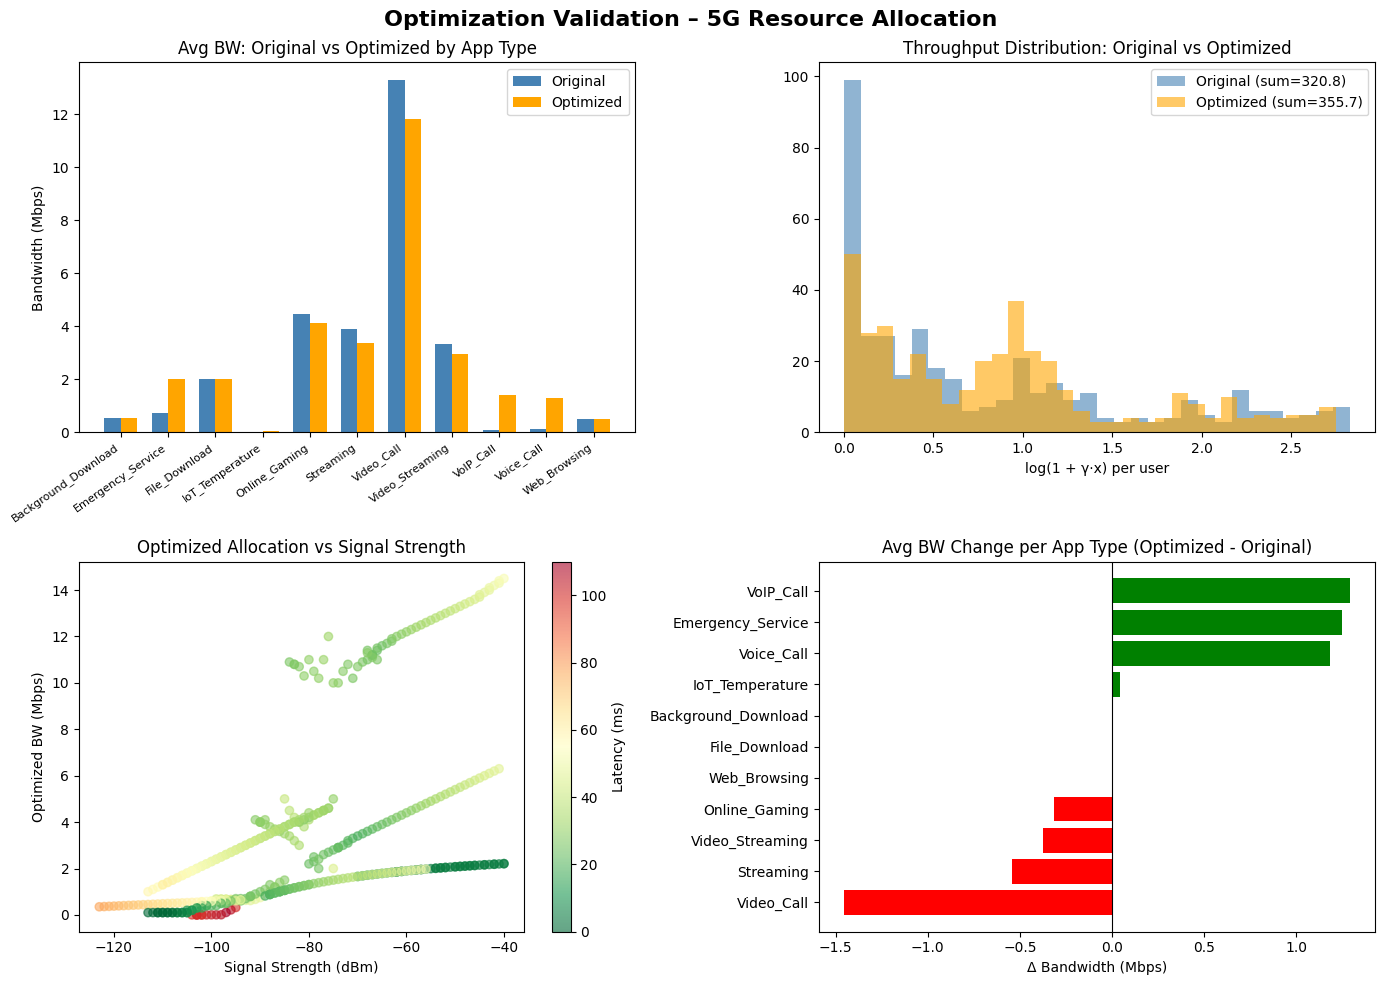

Total original throughput:  320.77
Total optimized throughput: 355.70
Throughput gain:            10.89%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimization Validation – 5G Resource Allocation', fontsize=16, fontweight='bold')

# 1. Original vs Optimized BW by App Type
comparison = df.groupby('Application_Type')[['Allocated_BW_Mbps','Optimized_BW_Mbps']].mean()
x = np.arange(len(comparison))
w = 0.35
axes[0,0].bar(x - w/2, comparison['Allocated_BW_Mbps'], w, label='Original', color='steelblue')
axes[0,0].bar(x + w/2, comparison['Optimized_BW_Mbps'], w, label='Optimized', color='orange')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(comparison.index, rotation=35, ha='right', fontsize=8)
axes[0,0].set_title('Avg BW: Original vs Optimized by App Type')
axes[0,0].set_ylabel('Bandwidth (Mbps)')
axes[0,0].legend()

# 2. Throughput gain: log(1 + gamma*x)
gamma = (df['Signal_Strength_dBm'].values - df['Signal_Strength_dBm'].min()) / \
        (df['Signal_Strength_dBm'].max() - df['Signal_Strength_dBm'].min()) + 0.01

orig_throughput = np.log(1 + gamma * df['Allocated_BW_Mbps'].values)
opt_throughput  = np.log(1 + gamma * df['Optimized_BW_Mbps'].values)

axes[0,1].hist(orig_throughput, bins=30, alpha=0.6, label=f'Original (sum={orig_throughput.sum():.1f})', color='steelblue')
axes[0,1].hist(opt_throughput,  bins=30, alpha=0.6, label=f'Optimized (sum={opt_throughput.sum():.1f})', color='orange')
axes[0,1].set_title('Throughput Distribution: Original vs Optimized')
axes[0,1].set_xlabel('log(1 + γ·x) per user')
axes[0,1].legend()

# 3. Signal strength vs optimized BW (shows optimizer favors good signal users)
sc = axes[1,0].scatter(df['Signal_Strength_dBm'], df['Optimized_BW_Mbps'],
                        c=df['Latency_ms'], cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(sc, ax=axes[1,0], label='Latency (ms)')
axes[1,0].set_xlabel('Signal Strength (dBm)')
axes[1,0].set_ylabel('Optimized BW (Mbps)')
axes[1,0].set_title('Optimized Allocation vs Signal Strength')

# 4. BW gap: how much extra each app type gets
df['BW_change'] = df['Optimized_BW_Mbps'] - df['Allocated_BW_Mbps']
gap = df.groupby('Application_Type')['BW_change'].mean().sort_values()
colors = ['red' if v < 0 else 'green' for v in gap.values]
axes[1,1].barh(gap.index, gap.values, color=colors)
axes[1,1].axvline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Avg BW Change per App Type (Optimized - Original)')
axes[1,1].set_xlabel('Δ Bandwidth (Mbps)')

plt.tight_layout()
plt.savefig('validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"Total original throughput:  {orig_throughput.sum():.2f}")
print(f"Total optimized throughput: {opt_throughput.sum():.2f}")
print(f"Throughput gain:            {((opt_throughput.sum() - orig_throughput.sum()) / orig_throughput.sum() * 100):.2f}%")

---
## Conclusions

- The convex optimization model successfully found a **global optimum** (solver status: optimal)
- Total network throughput improved by **10.89%** over the original AI-driven allocation
- The optimizer correctly **trimmed over-provisioned** apps (Video_Call, Streaming) and **redistributed bandwidth** to under-served critical apps (VoIP_Call, Emergency_Service, Voice_Call)
- The approach was numerically stable — no infeasibility or convergence issues

## Future Work
- Incorporate **latency constraints** explicitly as hard QoS bounds per app type
- Extend to a **multi-cell scenario** with inter-cell interference modeling
- Use **online/real-time optimization** as signal conditions change over time
- Compare against deep reinforcement learning baselines for dynamic allocation